# 03 Shots Data

Calculate state-specific and combined low-lying QSE errors across the fixed overlap-threshold ladder.

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd

from config import PROCESSED_DATAFRAMES_DIR
from notebook_utils.analysis import get_max_states
from notebook_utils.general import parse_active_space, save_figure
from notebook_utils.graphs import (plot_best_threshold_heatmap, plot_commuting_group_scaling,
                                   plot_correlated_error_distribution, plot_error_scaling_regression,
                                   plot_shot_eigenvalue_spread, plot_threshold_shot_errors,
                                   show_scrollable_figs)
from notebook_utils.mat_fn import general_solve, threshold_ladder_solve

SHOTS_DATAFRAME_PATH = PROCESSED_DATAFRAMES_DIR / "shots_qse_data.pkl"
df_shots = pd.read_pickle(SHOTS_DATAFRAME_PATH)

In [2]:
MEAN_KEYS = ["active_space", "ansatz", "n_shots", "molecule"]
SECTOR_STATES = {"singlet": 2, "triplet": 6}
FIXED_THRESHOLDS = np.logspace(-4, 0, 41)

mean_error_rows = []

# Group the entries by unique active space, ansatz, nshots and molecule
for key, df_group in df_shots.groupby(MEAN_KEYS, sort=True):
    active_space, ansatz, n_shots, molecule = key
    state_errors = []

    for expansion, max_sector_states in SECTOR_STATES.items():
        df_expansion = df_group[df_group["expansion"] == expansion]
        first_row = df_expansion.iloc[0]

        # Solve SV energies once first 
        sv_energies = general_solve(first_row["H_sv"], first_row["S_sv"], threshold=1e-8)[0]
        # num sector states is the number of states we retain, min of 2/6 or dimensions
        num_sector_states = min(len(sv_energies), max_sector_states)
        sv_energies = sv_energies[:num_sector_states]
        # Solve shot energies from the threshold ladder
        shot_energies = np.asarray([
            threshold_ladder_solve(row.H_shots, row.S_shots, FIXED_THRESHOLDS, num_sector_states)
            for row in df_expansion.itertuples(index=False)
        ])

        # Group triplet terms
        if expansion == "triplet":
            sv_energies = sv_energies.reshape(-1, 3).mean(axis=-1)
            shot_energies = shot_energies.reshape(*shot_energies.shape[:-1], -1, 3).mean(axis=-1)

        repeat_errors = 1000 * np.abs(shot_energies - sv_energies)
        state_errors.append(repeat_errors.mean(axis=0))

    mean_error_rows.append({
        **dict(zip(MEAN_KEYS, key)),
        "mean_error": np.concatenate(state_errors, axis=1).mean(axis=1),
    })

df_mean_errors = pd.DataFrame(mean_error_rows)

In [3]:
df_mean_errors

,active_space,ansatz,n_shots,molecule,mean_error
0,2e2o,UCCSD,1000,Acetamide,"[184.4548894530789, 184.4548894530789, 184.454..."
1,2e2o,UCCSD,1000,Acetone,"[41.630935027755335, 41.630935027755335, 41.63..."
2,2e2o,UCCSD,1000,Adenine,"[66.9355474788271, 66.9355474788271, 66.935547..."
3,2e2o,UCCSD,1000,Benzene,"[97.00580246535537, 97.00580246535537, 97.0058..."
4,2e2o,UCCSD,1000,Benzoquinone,"[342.97323468841046, 342.97323468841046, 342.9..."
...,...,...,...,...,...
1955,6e6o,UCCSD,1000000,Pyrrole,"[646.6832112318891, 556.9999642131869, 505.334..."
1956,6e6o,UCCSD,1000000,Tetrazine,"[819.8581689443702, 722.2847609612786, 518.320..."
1957,6e6o,UCCSD,1000000,Thymine,"[366.9830896735604, 354.9694722333044, 320.649..."
1958,6e6o,UCCSD,1000000,Triazine,"[813.7240262229227, 765.8967836416977, 726.630..."


## Error against Thresholding and Shot Count


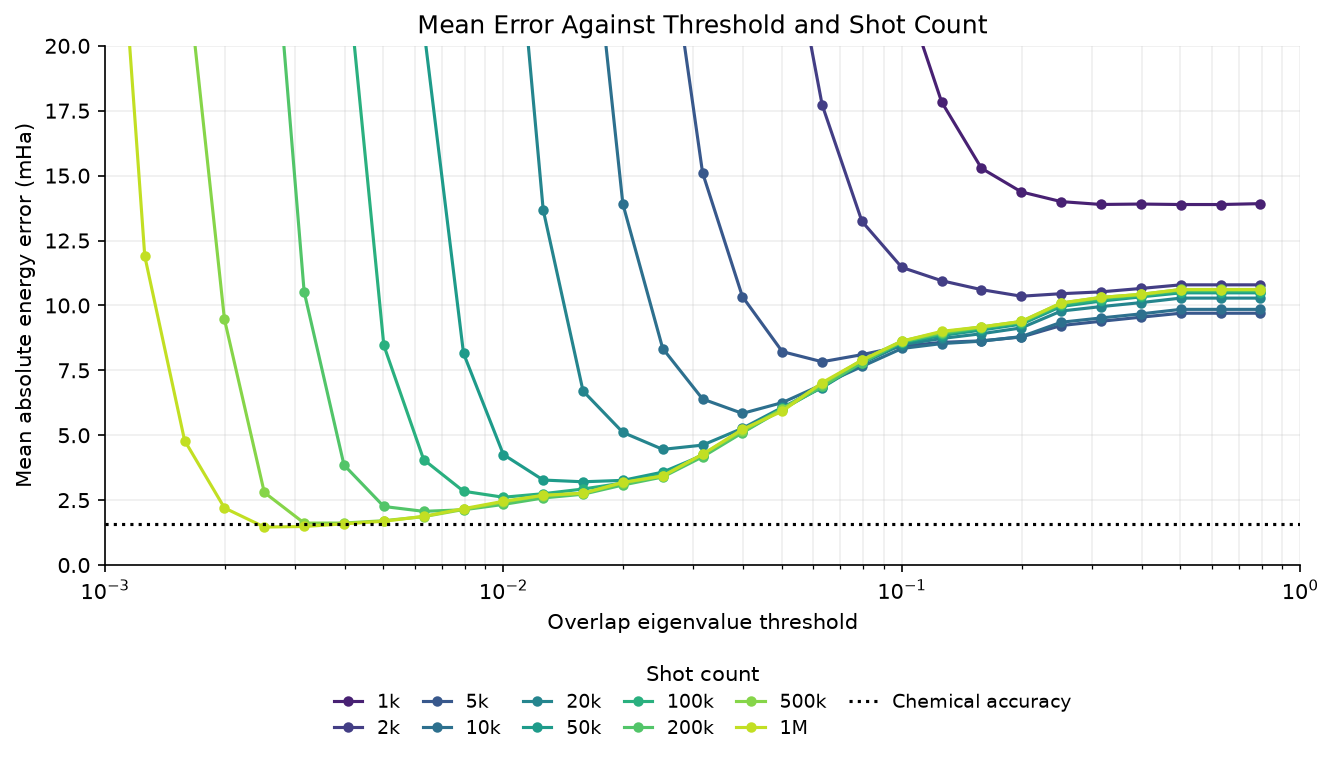

In [4]:
df_6e6o_errors = df_mean_errors[df_mean_errors["active_space"] == "6e6o"]
shot_threshold_errors = {}

for n_shots in sorted(df_6e6o_errors["n_shots"].unique()):
    df_shot_count = df_6e6o_errors[df_6e6o_errors["n_shots"] == n_shots]
    error_vectors = np.stack(df_shot_count["mean_error"])
    shot_threshold_errors[int(n_shots)] = error_vectors.mean(axis=0)

threshold_shot_figure = plot_threshold_shot_errors(shot_threshold_errors, FIXED_THRESHOLDS)
save_figure(threshold_shot_figure, "shots", "threshold_shot_error_6e6o")
show_scrollable_figs([threshold_shot_figure])

## Best threshold


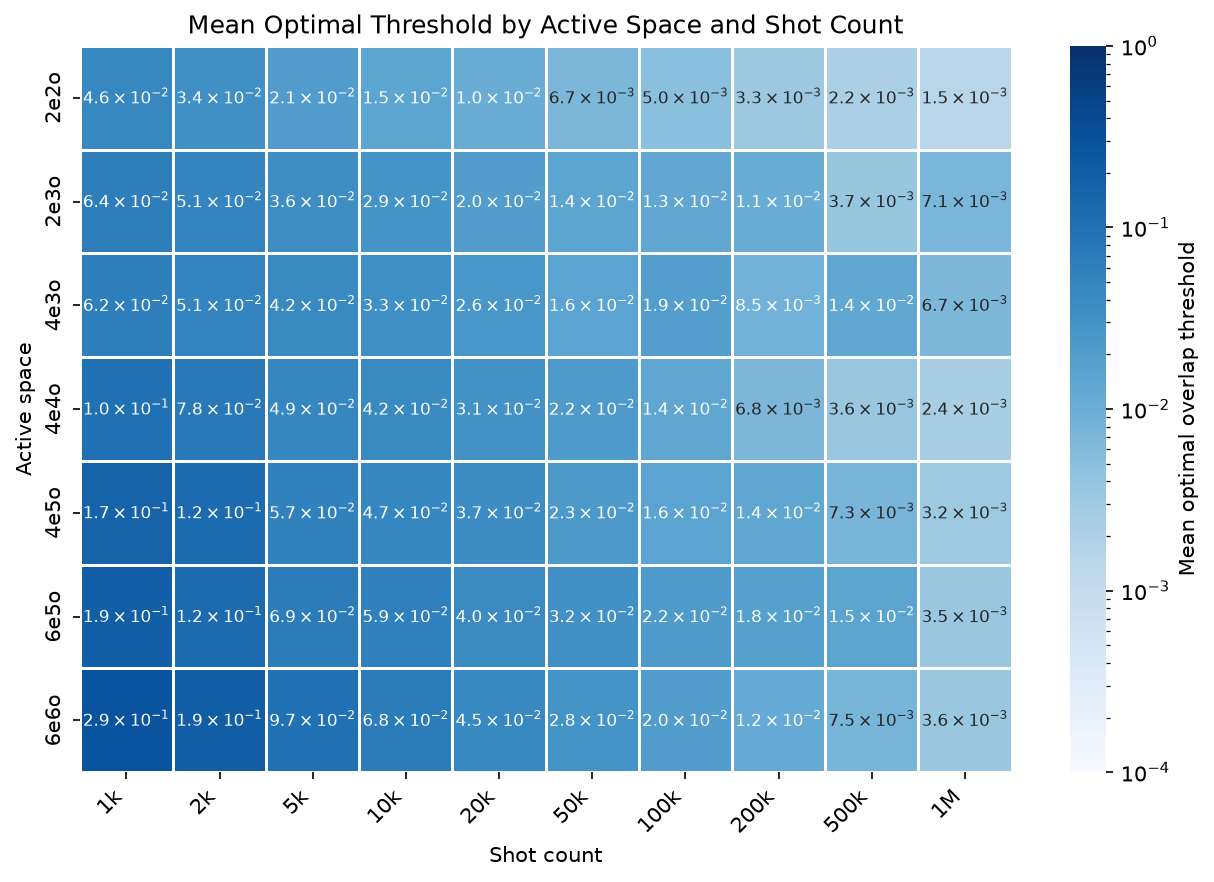

In [5]:
active_spaces = sorted(df_mean_errors["active_space"].unique(), key=parse_active_space)
shot_counts = sorted(df_mean_errors["n_shots"].unique())
best_threshold_data = {}

for active_space in active_spaces:
    df_active = df_mean_errors[df_mean_errors["active_space"] == active_space]
    best_threshold_data[active_space] = {}

    for n_shots in shot_counts:
        df_shot_count = df_active[df_active["n_shots"] == n_shots]
        molecule_thresholds = [
            FIXED_THRESHOLDS[np.nanargmin(errors)]
            for errors in df_shot_count["mean_error"]
        ]
        best_threshold_data[active_space][int(n_shots)] = np.mean(molecule_thresholds)

best_threshold_figure = plot_best_threshold_heatmap(best_threshold_data)
save_figure(best_threshold_figure, "shots", "best_threshold_heatmap")
show_scrollable_figs([best_threshold_figure])

## Active space scaling


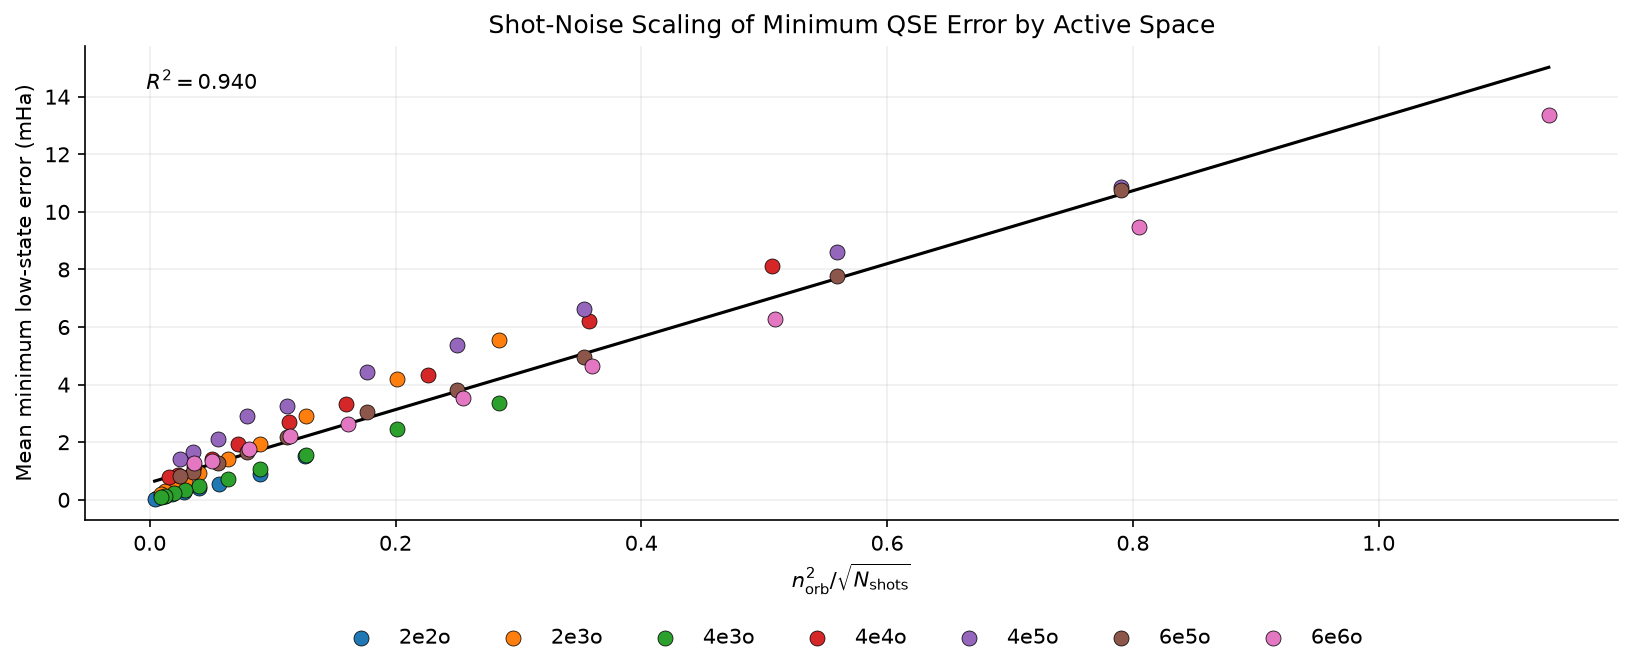

In [6]:
lowest_error_data = {}

for active_space in active_spaces:
    df_active = df_mean_errors[df_mean_errors["active_space"] == active_space]
    lowest_error_data[active_space] = {}

    for n_shots in shot_counts:
        df_shot_count = df_active[df_active["n_shots"] == n_shots]
        molecule_errors = [np.nanmin(errors) for errors in df_shot_count["mean_error"]]
        lowest_error_data[active_space][int(n_shots)] = np.mean(molecule_errors)

scaling_figure = plot_error_scaling_regression(lowest_error_data)
save_figure(scaling_figure, "shots", "active_space_shot_scaling_regression")
show_scrollable_figs([scaling_figure])

## Eigenvalue Lifting


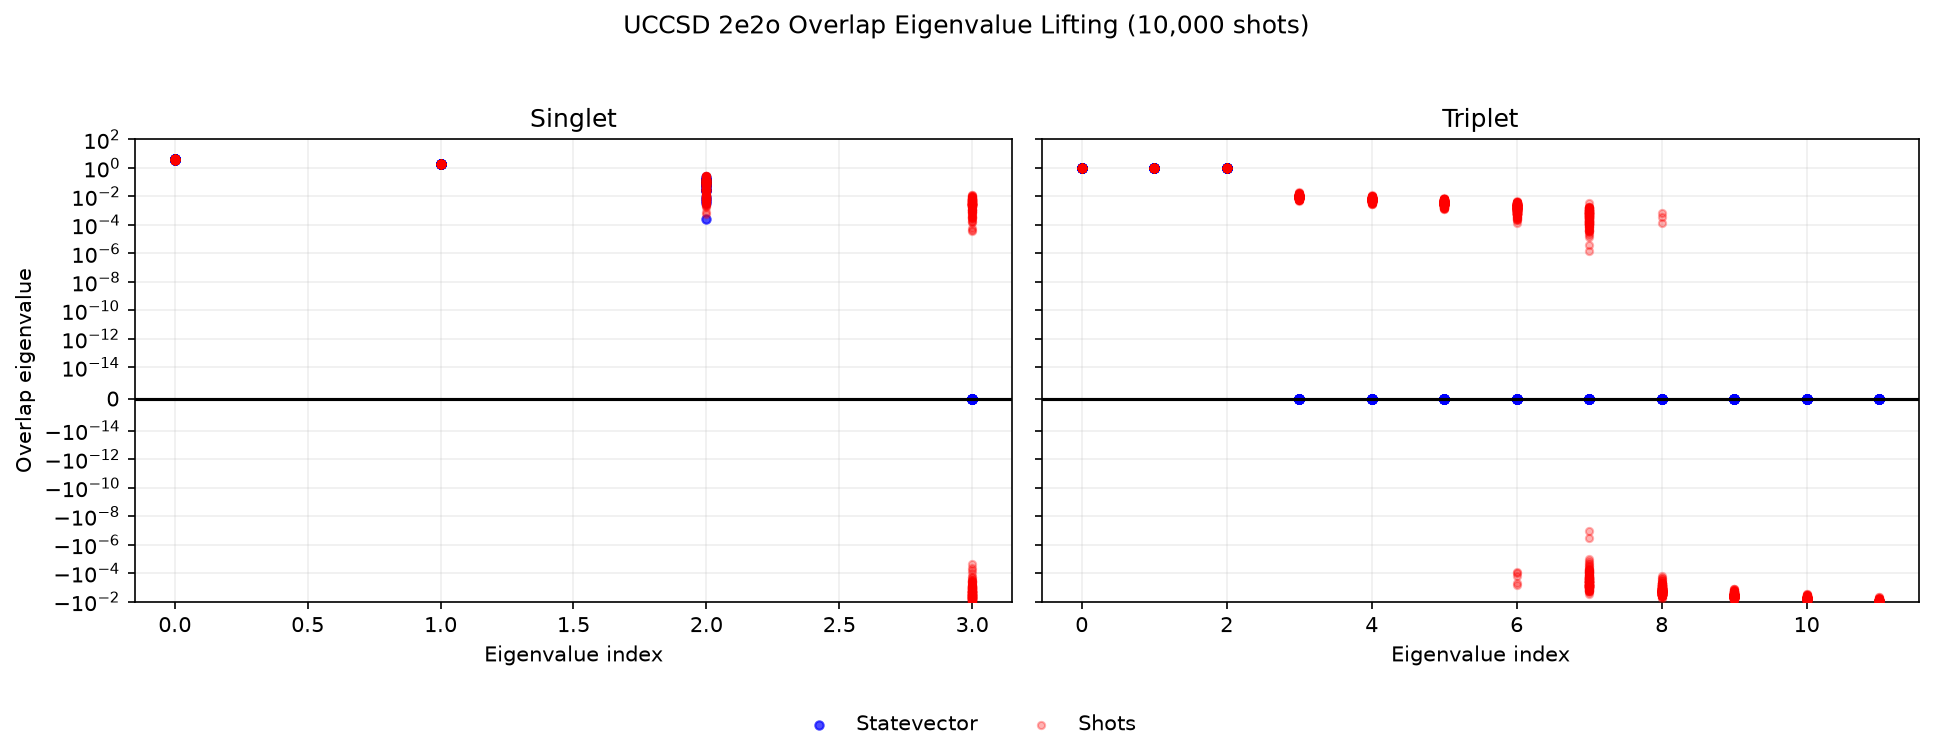
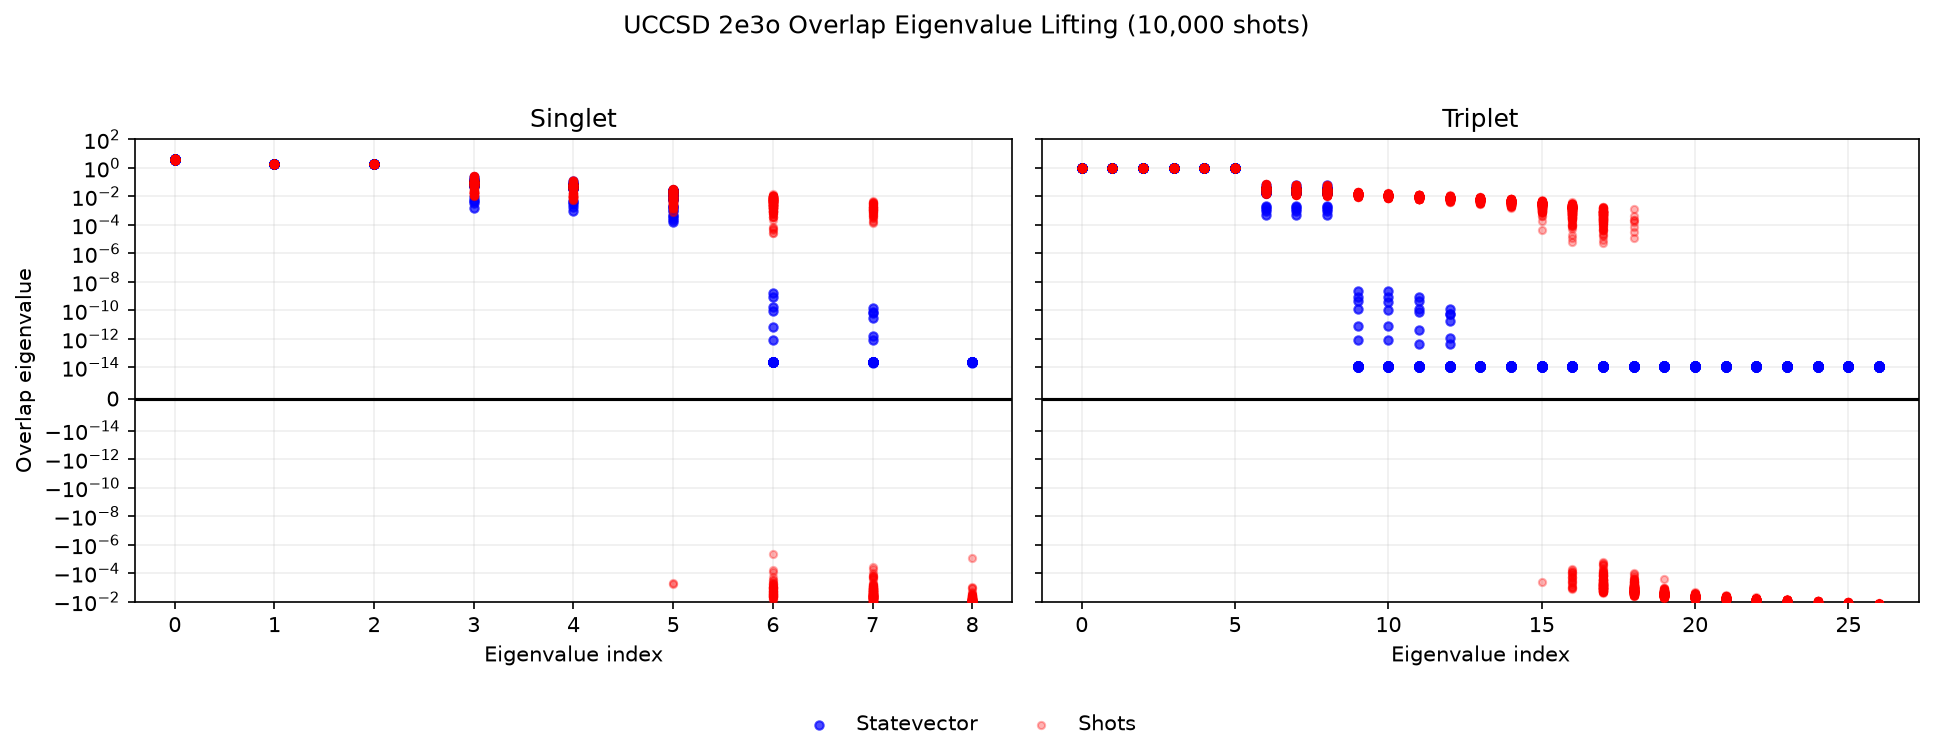
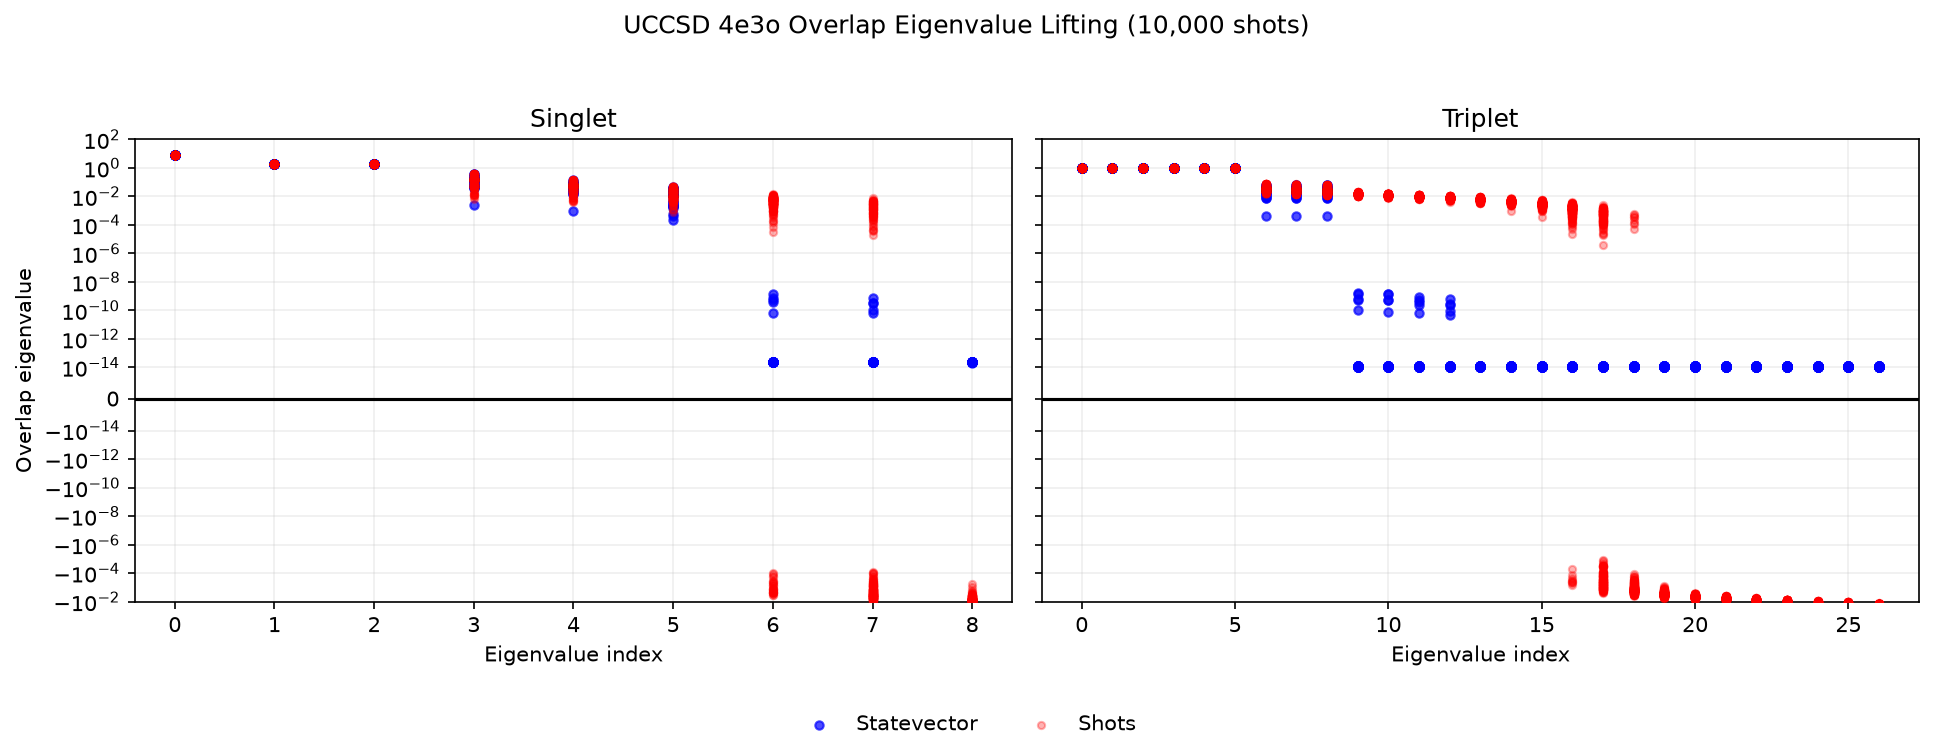
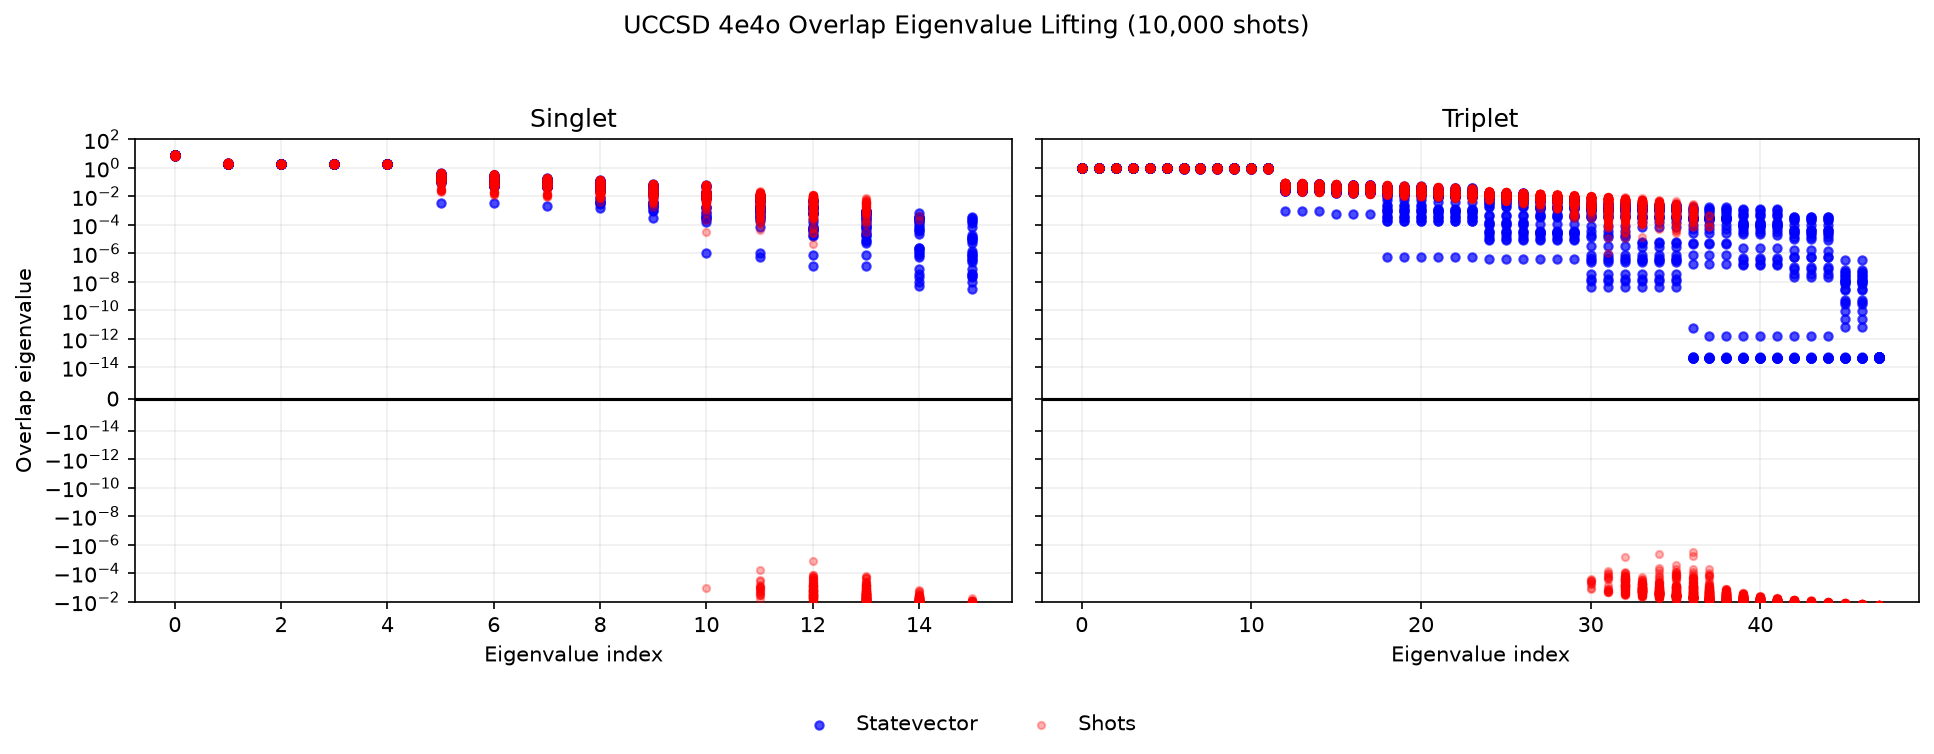
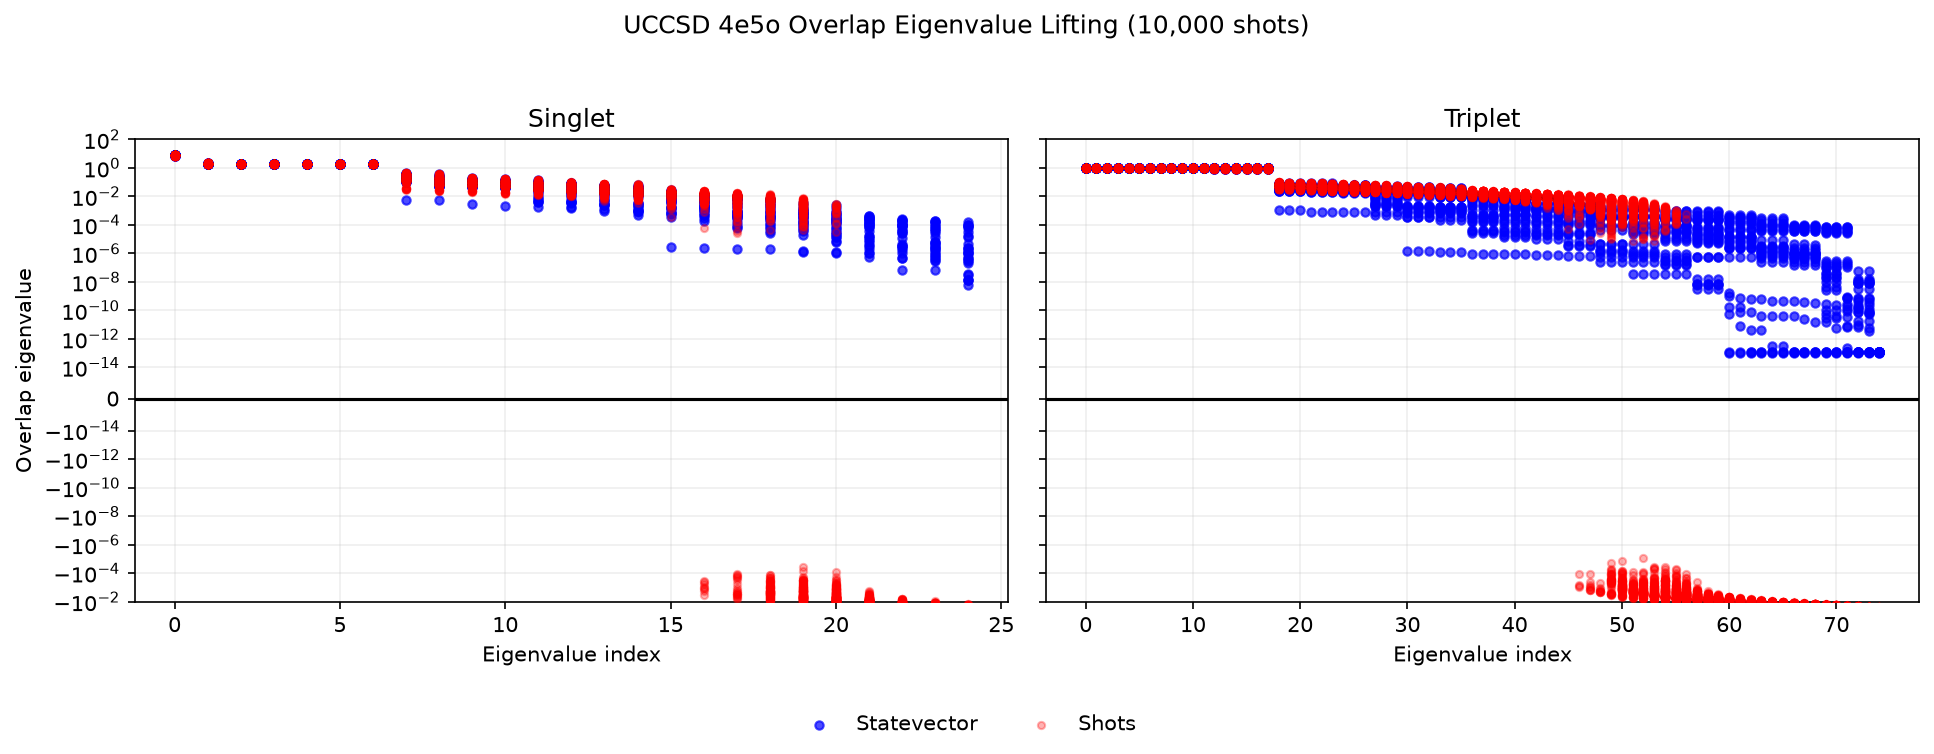
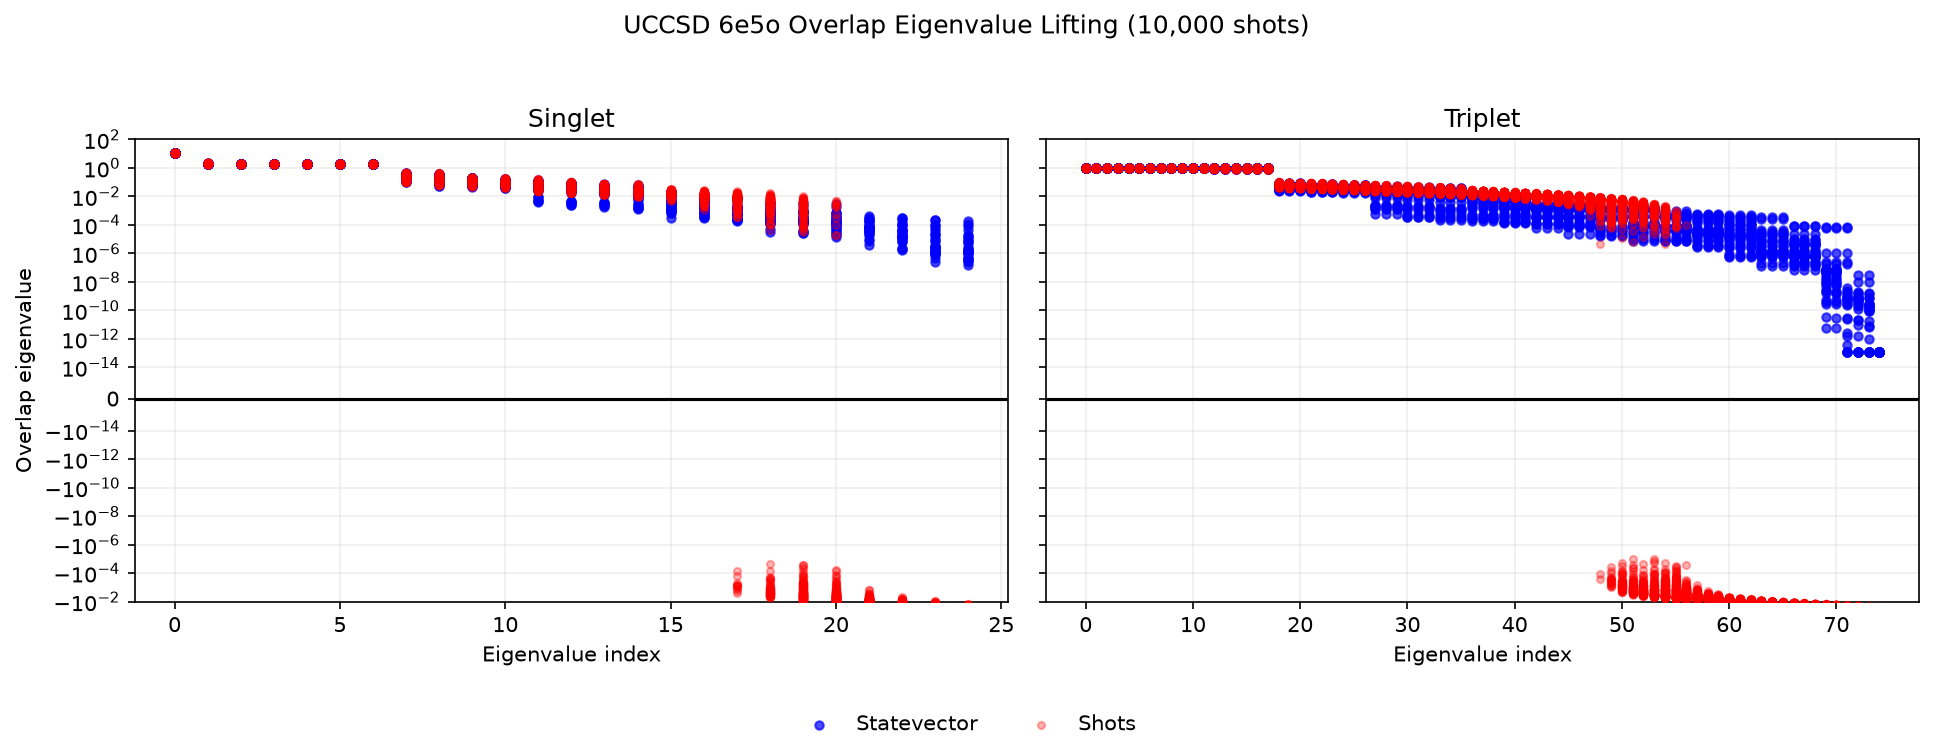
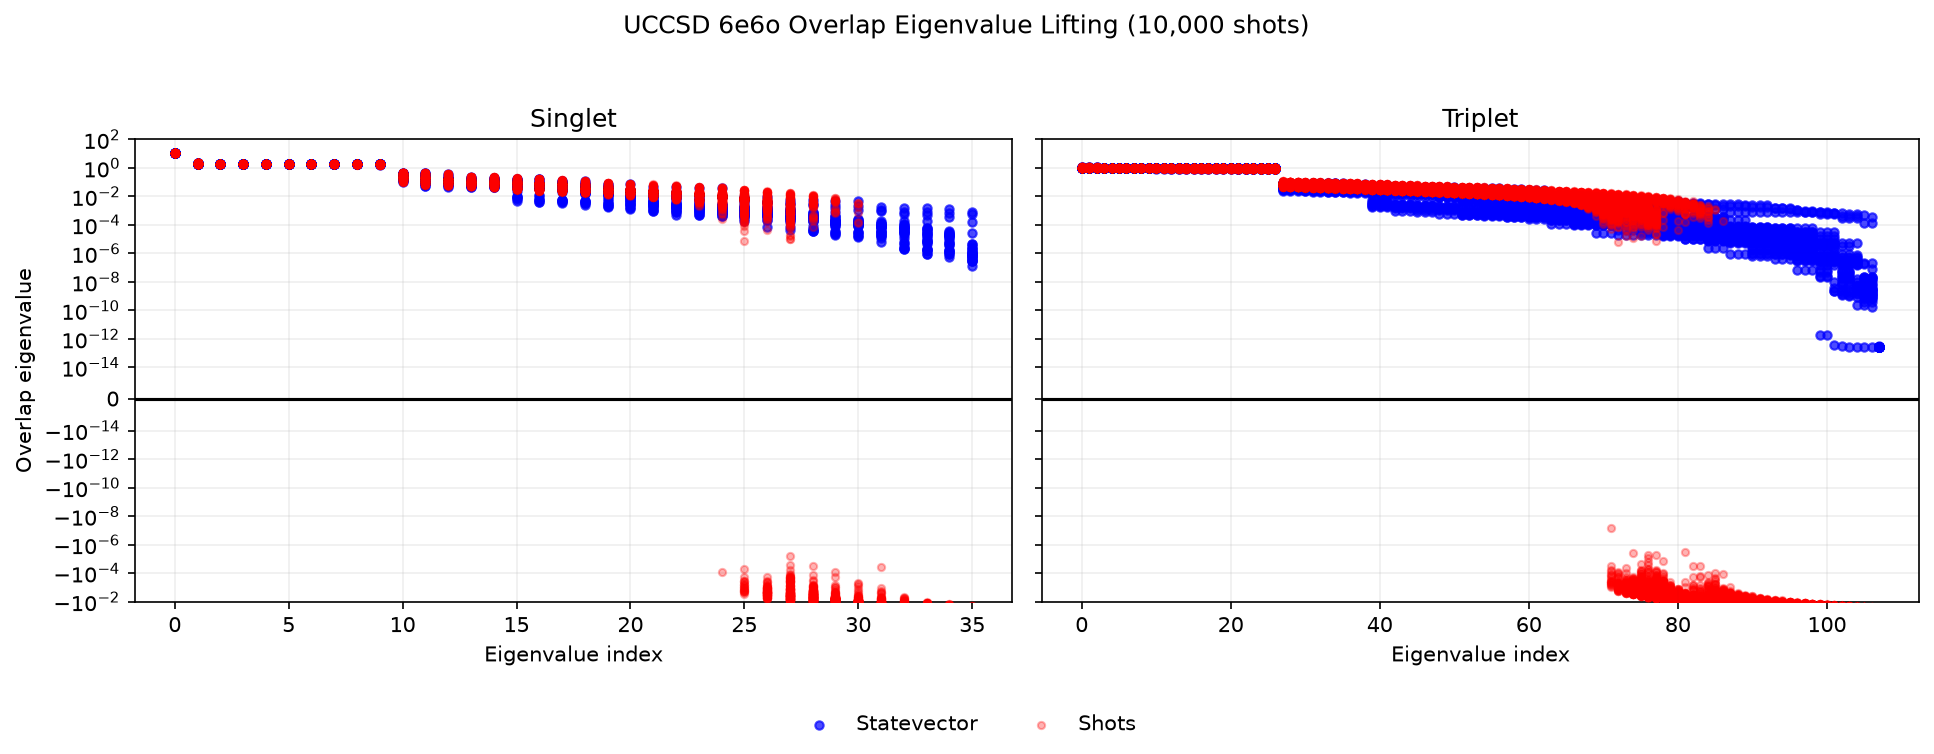

In [7]:
# Show the eigenvalues lifting effect under shot noise
eigenvalue_shot_count = 10_000
df_eigenvalue_shots = df_shots[df_shots["n_shots"] == eigenvalue_shot_count]
eigenvalue_lifting_data = {}
eigenvalue_lifting_figures = []

# Separate y active space and plot
for active_space in active_spaces:
    df_active = df_eigenvalue_shots[df_eigenvalue_shots["active_space"] == active_space]
    eigenvalue_data = {}

    for expansion in ("singlet", "triplet"):
        df_expansion = df_active[df_active["expansion"] == expansion]
        statevector_points = []
        shot_points = []

        # Save the SV eigenvalsh then shots one
        for S in df_expansion.drop_duplicates("molecule")["S_sv"]:
            eigenvalues = np.linalg.eigvalsh(np.asarray(S, dtype=complex)).real[::-1]
            statevector_points.extend(enumerate(eigenvalues))

        for S in df_expansion["S_shots"]:
            eigenvalues = np.linalg.eigvalsh(np.asarray(S, dtype=complex)).real[::-1]
            shot_points.extend(enumerate(eigenvalues))

        eigenvalue_data[expansion] = {
            "statevector": statevector_points,
            "shots": shot_points,
        }

    eigenvalue_lifting_data[active_space] = eigenvalue_data
    figure = plot_shot_eigenvalue_spread(eigenvalue_data, active_space, eigenvalue_shot_count)
    save_figure(figure, "shots/eigenvalue_lifting", f"uccsd_{active_space}")
    eigenvalue_lifting_figures.append(figure)

show_scrollable_figs(eigenvalue_lifting_figures)

## Total commuting groups scaling

In [8]:
df_commuting_groups = df_shots[
    (df_shots["ansatz"] == "UCCSD")
    & (df_shots["n_shots"] == 1_000)
    & (df_shots["repeat"] == 0)
]


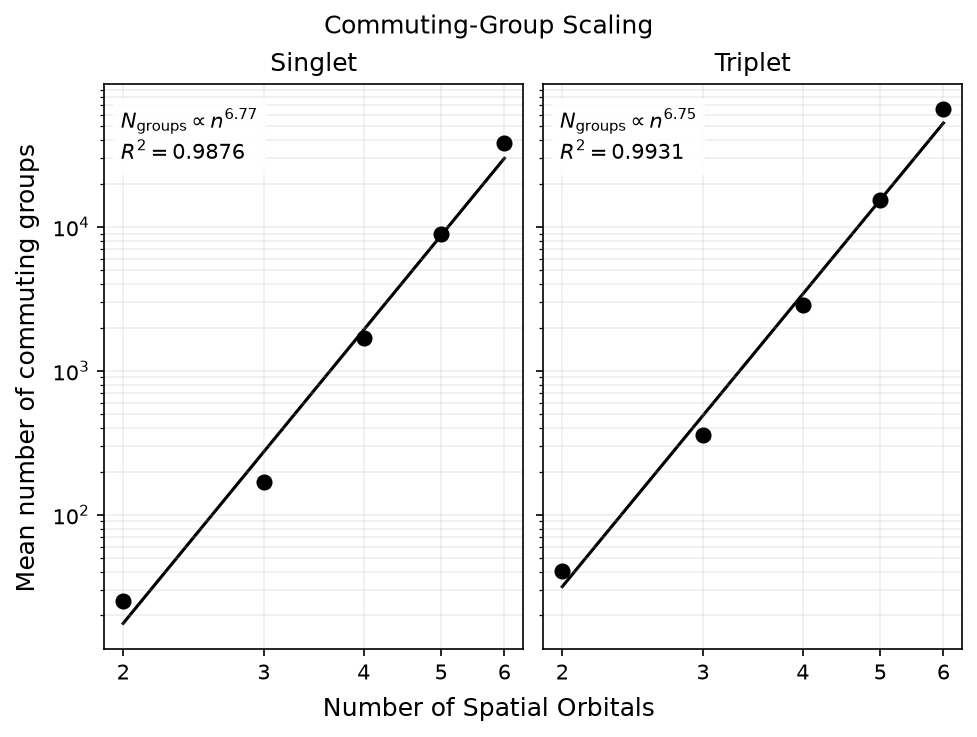

In [9]:
commuting_group_data = {}
for expansion in ["singlet", "triplet"]:
    df_expansion = df_commuting_groups[df_commuting_groups["expansion"] == expansion].copy()
    df_expansion["num_orbitals"] = df_expansion["active_space"].map(parse_active_space).str[1]
    commuting_group_data[expansion] = (
        df_expansion.groupby("num_orbitals")["num_commuting_groups"].mean().to_dict()
    )

commuting_group_figure = plot_commuting_group_scaling(
    commuting_group_data
)
save_figure(commuting_group_figure, "scaling_future_work", "commuting_group_scaling")
show_scrollable_figs([commuting_group_figure])


## Correlated Errors

,condition,count,mean_mHa,median_mHa,iqr_mHa,min_mHa,max_mHa
0,Matched noisy H/S,280,2.61,2.12,1.97,0.312,15.9
1,Shifted noisy H/S,280,4.34e+04,3.62e+04,3.13e+04,2.96e+03,1.32e+05
2,Noisy H / statevector S,280,4.23e+04,3.04e+04,3.49e+04,1.64e+03,1.4e+05



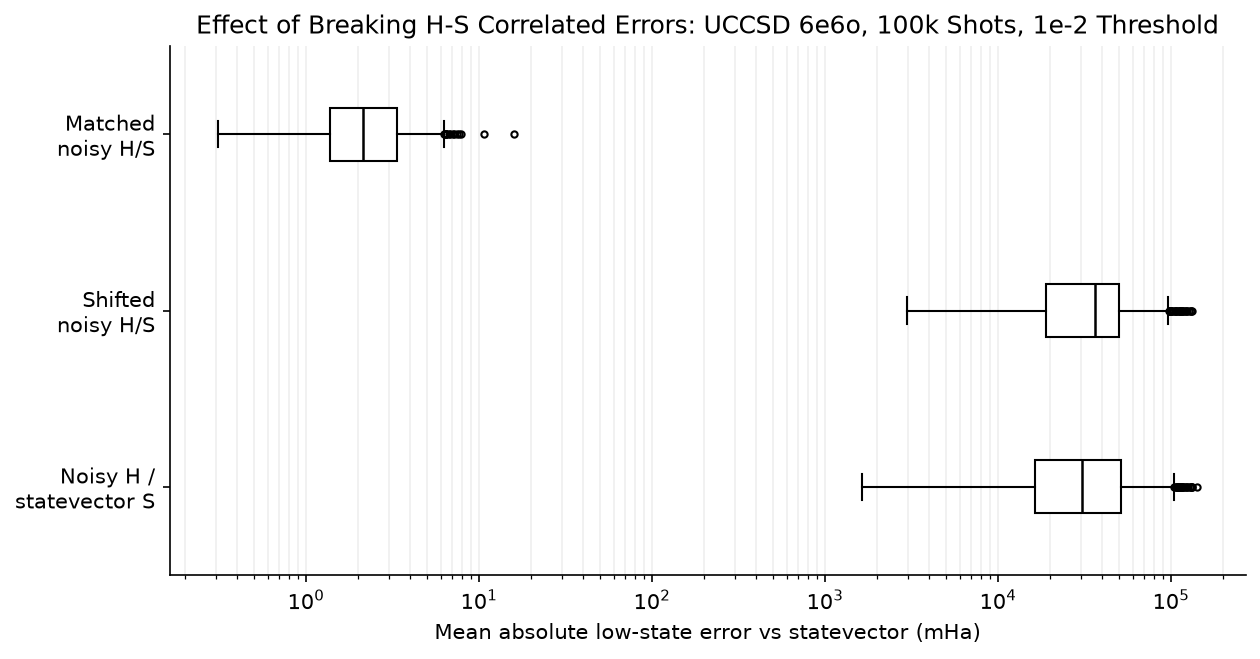

In [10]:
CORRELATED_ACTIVE_SPACE = "6e6o"
CORRELATED_N_SHOTS = 100_000
CORRELATED_THRESHOLD = 1e-2
CONDITIONS = ["Matched noisy H/S", "Shifted noisy H/S", "Noisy H / statevector S"]

df_correlated_source = df_shots[
    (df_shots["active_space"] == CORRELATED_ACTIVE_SPACE)
    & (df_shots["n_shots"] == CORRELATED_N_SHOTS)
    & (df_shots["ansatz"] == "UCCSD")
].copy()

state_error_rows = []

for (molecule, expansion), df_group in df_correlated_source.groupby(["molecule", "expansion"], sort=False):
    repeat_rows = df_group.set_index("repeat").loc[range(10)]
    num_sector_states = 2 if expansion == "singlet" else 6
    reference_energies = general_solve(
        repeat_rows.iloc[0]["H_sv"], repeat_rows.iloc[0]["S_sv"], threshold=1e-8
    )[0][:num_sector_states]

    for repeat_index, (_, row) in enumerate(repeat_rows.iterrows()):
        matrix_pairs = {
            "Matched noisy H/S": (row["H_shots"], row["S_shots"]),
            "Shifted noisy H/S": (row["H_shots"], repeat_rows.iloc[(repeat_index + 1) % len(repeat_rows)]["S_shots"]),
            "Noisy H / statevector S": (row["H_shots"], row["S_sv"]),
        }

        for condition, (H, S) in matrix_pairs.items():
            energies = threshold_ladder_solve(H, S, [CORRELATED_THRESHOLD], num_sector_states)[0]
            if expansion == "triplet":
                states = ("t1", "t2")
                exact_energies = reference_energies.reshape(-1, 3).mean(axis=1)
                energies = energies.reshape(-1, 3).mean(axis=1)
            else:
                states = ("s0", "s1")
                exact_energies = reference_energies

            for state, energy, exact_energy in zip(states, energies, exact_energies):
                state_error_rows.append({
                    "molecule": molecule, "repeat": repeat_index, "condition": condition,
                    "state": state, "error_mHa": 1000 * abs(energy - exact_energy),
                })

df_correlated_error_states = pd.DataFrame(state_error_rows)
df_correlated_error_means = (
    df_correlated_error_states.groupby(["molecule", "repeat", "condition"], as_index=False)["error_mHa"]
    .mean()
    .rename(columns={"error_mHa": "mean_error_mHa"})
)
df_correlated_error_means["condition"] = pd.Categorical(
    df_correlated_error_means["condition"], CONDITIONS, ordered=True
)
df_correlated_error_summary = (
    df_correlated_error_means.groupby("condition", observed=True)["mean_error_mHa"]
    .agg(
        count="count",
        mean_mHa="mean",
        median_mHa="median",
        iqr_mHa=lambda values: values.quantile(0.75) - values.quantile(0.25),
        min_mHa="min",
        max_mHa="max",
    )
    .reindex(CONDITIONS)
    .reset_index()
)
display(df_correlated_error_summary.style.format({
    "mean_mHa": "{:.3g}", "median_mHa": "{:.3g}", "iqr_mHa": "{:.3g}",
    "min_mHa": "{:.3g}", "max_mHa": "{:.3g}",
}).set_caption("Correlated-error distribution summary (mHa)"))
correlated_error_figure = plot_correlated_error_distribution(df_correlated_error_means)
save_figure(correlated_error_figure, "scaling_future_work", "breaking_hs_correlated_errors")
show_scrollable_figs([correlated_error_figure])